In [10]:
%pip install scikit-learn seaborn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, OneHotEncoder
from sklearn.metrics import roc_auc_score, accuracy_score
import pickle

# 1. Carregando os dados REAIS (lembre-se de usar o arquivo completo no seu PC)
# df = pd.read_csv('data/abt_churn.csv')

# Simulando o carregamento da base para o código (use a linha de cima na real)
df = pd.read_csv('data/abt_churn.csv')

# Converte a coluna de data para o formato datetime para podermos achar o "último mês"
df['dtRef'] = pd.to_datetime(df['dtRef'])

Para garantir que o modelo seja testado no 'mundo real' e evitar o vazamento de dados (data leakage), a primeira decisão foi isolar a safra cronológica mais recente como base Out-of-Time (OOT). Em seguida, fizemos a divisão 80/20 estratificada para manter a mesma severidade de churn em todas as fatias.

In [12]:
# 1.1 Out-of-Time (OOT): Isolando a safra mais recente
ultimo_mes = df['dtRef'].max() # Descobre qual é a data mais recente na base
df_oot = df[df['dtRef'] == ultimo_mes].copy()
df_model = df[df['dtRef'] < ultimo_mes].copy()

print(f"O mês isolado para OOT (Teste Cego) foi: {ultimo_mes.strftime('%Y-%m')}")

# 1.2 Separando as Features (X) do Target (y)
colunas_para_remover =['dtRef', 'idUsuario', 'flagChurn']
X = df_model.drop(columns=colunas_para_remover)
y = df_model['flagChurn']

# 1.3 Train/Test Split com Estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Volume - Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]} | OOT: {df_oot.shape[0]}")

O mês isolado para OOT (Teste Cego) foi: 2025-04
Volume - Treino: 4154 | Teste: 1039 | OOT: 303


In [13]:
# 2.1 Verificação de Qualidade (Valores Nulos)
nulos = X_train.isnull().sum()
print("Colunas com valores nulos no Treino:")
print(nulos[nulos > 0])

# 2.2 Análise Bivariada (Comportamento vs Target)
df_analise = X_train.copy()
df_analise['target'] = y_train

# Vamos ver a média de algumas variáveis de engajamento para quem deu Churn vs Não deu Churn
vars_analise = ['qtdeTransacoes', 'saldoPontos', 'qtdeDiasUltimaTransacao']
resumo_bivariado = df_analise.groupby('target')[vars_analise].mean().T
print("\nAnálise Bivariada (Médias):")
print(resumo_bivariado)

# 2.3 Feature Importance Preliminar (Árvore Rápida)
# Preenchendo nulos temporariamente apenas para o Raio-X
X_train_raiox = X_train.fillna(-999)
arvore_raiox = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore_raiox.fit(X_train_raiox, y_train)

importancias = pd.Series(arvore_raiox.feature_importances_, index=X_train.columns)
print("\nTop 5 Variáveis mais promissoras pelo Raio-X:")
print(importancias.sort_values(ascending=False).head(5))

Colunas com valores nulos no Treino:
Series([], dtype: int64)

Análise Bivariada (Médias):
target                             0           1
qtdeTransacoes            326.906618   50.051335
saldoPontos              1451.726201  439.316735
qtdeDiasUltimaTransacao     6.687670   13.425051

Top 5 Variáveis mais promissoras pelo Raio-X:
qtdeDiasD14                0.659739
propAvgQtdeDias            0.107115
qtdeDiasUltimaTransacao    0.055519
qtdeTransacoesD7           0.044673
qtdePontosPosD7            0.037695
dtype: float64


In [14]:
# 3.1 Definindo grupos de variáveis
# Escolhendo colunas para transformar em faixas de risco (Binning)
vars_binning =['qtdeDiasUltimaTransacao', 'saldoPontos']

# O restante das colunas numéricas vão sofrer padronização geométrica (StandardScaler)
vars_numericas = [col for col in X_train.columns if col not in vars_binning]

# 3.2 Construindo a engenharia do Pipeline (ColumnTransformer)
modificador = ColumnTransformer(transformers=[
    # Discretiza e depois aplica One-Hot Encoding
    ('binning', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('binner', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), vars_binning),

    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), vars_numericas)
])

Decisão metodológica: Optamos por encapsular toda a transformação matemática (Discretização, Imputação da Mediana e StandardScaler) utilizando a classe Pipeline e ColumnTransformer. Isso garante a padronização, evita que erros aconteçam ao aplicar nos dados de teste e blinda o modelo para ir para produção (MLOps).

In [15]:
# 4.1 Encapsulamento completo (Governança)
pipeline_completo = Pipeline([
    ('prep', modificador),
    ('rf', RandomForestClassifier(random_state=42))
])

# 4.2 Grade Tática de Batalha (Hyperparameter Tuning)
parametros = {
    'rf__n_estimators': [100, 150],
    'rf__max_depth': [5, 10]
}

# 4.3 Treinamento com Validação Cruzada (Cross-Validation)
print("Iniciando treinamento com GridSearchCV. Pode levar alguns minutos...")
grid = GridSearchCV(
    pipeline_completo,
    param_grid=parametros,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(f"\nMelhor combinação de parâmetros: {grid.best_params_}")

Iniciando treinamento com GridSearchCV. Pode levar alguns minutos...


c:\Users\a\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(



Melhor combinação de parâmetros: {'rf__max_depth': 5, 'rf__n_estimators': 100}



--- Métricas ROC AUC e ACURÁCIA ---
Treino -> ROC AUC: 0.8402 | Acc: 0.7573
Teste  -> ROC AUC: 0.8284 | Acc: 0.7536
OOT    -> ROC AUC: 0.8398 | Acc: 0.7756

--- Auditoria de Negócio (Gains) ---
Se acionarmos os 10% com maior risco, evitamos 18.3% de todo o Churn.
Se acionarmos os 20% com maior risco, evitamos 34.9% de todo o Churn.
Se acionarmos os 30% com maior risco, evitamos 49.3% de todo o Churn.


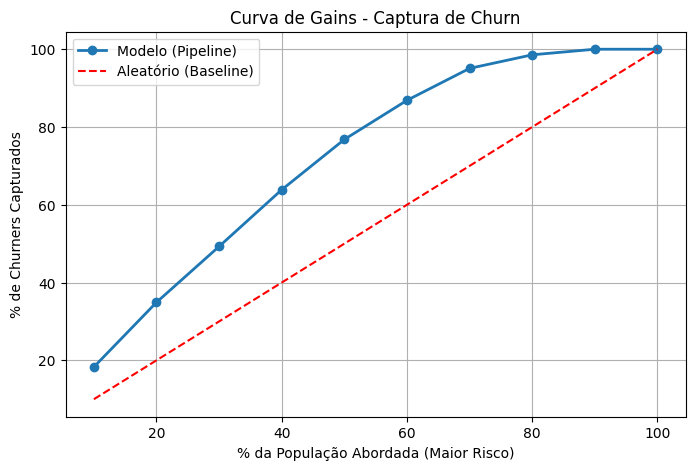


Pipeline selado e salvo com versionamento automático em: 'models/motor_churn_v1.pkl'.


In [17]:
import os
import re
import pickle

# 5.1 Preparação cega na base OOT
X_oot = df_oot.drop(columns=colunas_para_remover)
y_oot = df_oot['flagChurn']

# 5.2 Previsões
# a) Probabilidades (necessárias para ROC AUC e Lift/Gains)
y_prob_treino = grid.predict_proba(X_train)[:, 1]
y_prob_teste = grid.predict_proba(X_test)[:, 1]
y_prob_oot = grid.predict_proba(X_oot)[:, 1]

# b) Classes Preditivas [0 ou 1] (necessárias para Acurácia)
y_pred_treino = grid.predict(X_train)
y_pred_teste = grid.predict(X_test)
y_pred_oot = grid.predict(X_oot)

# 5.3 Métricas de Performance (Estabilidade)
print("\n--- Métricas ROC AUC e ACURÁCIA ---")
print(f"Treino -> ROC AUC: {roc_auc_score(y_train, y_prob_treino):.4f} | Acc: {accuracy_score(y_train, y_pred_treino):.4f}")
print(f"Teste  -> ROC AUC: {roc_auc_score(y_test, y_prob_teste):.4f} | Acc: {accuracy_score(y_test, y_pred_teste):.4f}")
print(f"OOT    -> ROC AUC: {roc_auc_score(y_oot, y_prob_oot):.4f} | Acc: {accuracy_score(y_oot, y_pred_oot):.4f}")

# 5.4 Análise de Negócio (Lift/Gains)
df_gains = pd.DataFrame({'Alvo_Real': y_test, 'Probabilidade_Modelo': y_prob_teste})
df_gains = df_gains.sort_values(by='Probabilidade_Modelo', ascending=False)

# Dividindo a população de teste em 10 grupos de risco (Decis)
df_gains['Decil'] = pd.qcut(range(len(df_gains)), 10, labels=False)

# Calculando o % de Churners capturados por decil
captura_acumulada = df_gains.groupby('Decil')['Alvo_Real'].sum().cumsum() / df_gains['Alvo_Real'].sum() * 100

print("\n--- Auditoria de Negócio (Gains) ---")
print(f"Se acionarmos os 10% com maior risco, evitamos {captura_acumulada.iloc[0]:.1f}% de todo o Churn.")
print(f"Se acionarmos os 20% com maior risco, evitamos {captura_acumulada.iloc[1]:.1f}% de todo o Churn.")
print(f"Se acionarmos os 30% com maior risco, evitamos {captura_acumulada.iloc[2]:.1f}% de todo o Churn.")

df_gains_plot = captura_acumulada.reset_index()
df_gains_plot['Decil'] = (df_gains_plot['Decil'] + 1) * 10 # Transforma em % 10, 20, 30...
df_gains_plot['Aleatorio'] = df_gains_plot['Decil'] # Se pego 10% da base ao acaso, pego 10% do churn

plt.figure(figsize=(8, 5))
plt.plot(df_gains_plot['Decil'], df_gains_plot['Alvo_Real'], marker='o', label='Modelo (Pipeline)', linewidth=2)
plt.plot(df_gains_plot['Decil'], df_gains_plot['Aleatorio'], linestyle='--', color='red', label='Aleatório (Baseline)')
plt.title('Curva de Gains - Captura de Churn')
plt.xlabel('% da População Abordada (Maior Risco)')
plt.ylabel('% de Churners Capturados')
plt.legend()
plt.grid(True)
plt.show()
# 5.5 Serialização Industrial do Artefato Final
pasta_modelos = 'models'

os.makedirs(pasta_modelos, exist_ok=True)

# 1. Procura todos os arquivos na pasta models que começam com 'motor_churn_v'
arquivos_existentes = os.listdir(pasta_modelos)
versoes =[]

for arquivo in arquivos_existentes:

    match = re.search(r'motor_churn_v(\d+)\.pkl', arquivo)
    if match:
        versoes.append(int(match.group(1)))

# 2. Define a próxima versão
if versoes:
    proxima_versao = max(versoes) + 1
else:
    proxima_versao = 1

# 3. Monta o nome final do arquivo com a nova versão
nome_arquivo = f'{pasta_modelos}/motor_churn_v{proxima_versao}.pkl'

# 4. Salva o modelo com o novo nome
with open(nome_arquivo, 'wb') as file:
    pickle.dump(grid.best_estimator_, file)
    
print(f"\nPipeline selado e salvo com versionamento automático em: '{nome_arquivo}'.")

A auditoria de qualidade do modelo foca em provar a estabilidade. Comparando o ROC AUC e Acurácia nas bases de Treino, Teste e OOT, validamos a ausência de Overfitting. Por fim, a Curva de Gains traduz a matemática em ROI de negócio.